In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from mlxtend.frequent_patterns import apriori, association_rules
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
df = pd.read_excel("data.xlsx")

In [4]:
print("Shape:", df.shape)

Shape: (3000, 12)


In [5]:
df.head()

,OrderID,CustomerID,Restaurant,FoodItem,Quantity,OrderValue,TotalAmount,DeliveryTime_Minutes,CustomerRating,City,PaymentMethod,OrderDate
0,1,1229,Biryani House,Pizza,1,465.61,465.61,57,1,Delhi,UPI,2024-05-05
1,2,1224,Healthy Bowl,Wrap,4,96.53,386.12,42,5,Chennai,Cash,2024-02-17
2,3,1604,Taco Town,Salad,5,298.15,1490.75,10,2,Mumbai,Card,2024-08-17
3,4,1105,Pizza Point,Taco,2,191.96,383.92,34,1,Hyderabad,Card,2024-06-21
4,5,1550,Pizza Point,Wrap,3,499.71,1499.13,34,1,Delhi,Card,2024-08-23


In [6]:
df.tail()

,OrderID,CustomerID,Restaurant,FoodItem,Quantity,OrderValue,TotalAmount,DeliveryTime_Minutes,CustomerRating,City,PaymentMethod,OrderDate
2995,2996,1024,Sushi Spot,Sandwich,5,561.70,2808.50,24,3,Mumbai,Cash,2024-04-24
2996,2997,1792,Pizza Point,Burger,2,321.62,643.24,52,2,Chennai,UPI,2024-10-26
2997,2998,1738,Sushi Spot,Wrap,4,210.30,841.20,48,5,Chennai,Card,2024-05-02
2998,2999,1505,Pasta Place,Pasta,5,248.04,1240.20,47,5,Hyderabad,Cash,2024-06-25
2999,3000,1590,Burger Hub,Burger,5,474.97,2374.85,36,5,Mumbai,Cash,2024-04-05


In [7]:
df.shape

(3000, 12)

In [8]:
df.columns.tolist()

['OrderID',
 'CustomerID',
 'Restaurant',
 'FoodItem',
 'Quantity',
 'OrderValue',
 'TotalAmount',
 'DeliveryTime_Minutes',
 'CustomerRating',
 'City',
 'PaymentMethod',
 'OrderDate']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   OrderID               3000 non-null   int64  
 1   CustomerID            3000 non-null   int64  
 2   Restaurant            3000 non-null   object 
 3   FoodItem              3000 non-null   object 
 4   Quantity              3000 non-null   int64  
 5   OrderValue            3000 non-null   float64
 6   TotalAmount           3000 non-null   float64
 7   DeliveryTime_Minutes  3000 non-null   int64  
 8   CustomerRating        3000 non-null   int64  
 9   City                  3000 non-null   object 
 10  PaymentMethod         3000 non-null   object 
 11  OrderDate             3000 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 281.4+ KB


In [11]:
df.dtypes

OrderID                   int64
CustomerID                int64
Restaurant               object
FoodItem                 object
Quantity                  int64
OrderValue              float64
TotalAmount             float64
DeliveryTime_Minutes      int64
CustomerRating            int64
City                     object
PaymentMethod            object
OrderDate                object
dtype: object

In [12]:
df.describe(include="all")

,OrderID,CustomerID,Restaurant,FoodItem,Quantity,OrderValue,TotalAmount,DeliveryTime_Minutes,CustomerRating,City,PaymentMethod,OrderDate
count,3000.000000,3000.000000,3000,3000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000,3000,3000
unique,NaN,NaN,10,10,NaN,NaN,NaN,NaN,NaN,5,3,364
top,NaN,NaN,Healthy Bowl,Wrap,NaN,NaN,NaN,NaN,NaN,Delhi,UPI,2024-07-10
freq,NaN,NaN,328,332,NaN,NaN,NaN,NaN,NaN,629,1050,19
mean,1500.500000,1397.573000,NaN,NaN,2.994333,338.074453,1009.472437,34.916333,3.002333,NaN,NaN,NaN
std,866.169729,233.609663,NaN,NaN,1.421141,149.676468,680.124564,14.943285,1.405342,NaN,NaN,NaN
min,1.000000,1001.000000,NaN,NaN,1.000000,80.050000,80.050000,10.000000,1.000000,NaN,NaN,NaN
25%,750.750000,1187.000000,NaN,NaN,2.000000,209.707500,458.070000,22.000000,2.000000,NaN,NaN,NaN
50%,1500.500000,1392.500000,NaN,NaN,3.000000,335.030000,853.350000,35.000000,3.000000,NaN,NaN,NaN
75%,2250.250000,1604.000000,NaN,NaN,4.000000,467.722500,1465.052500,48.000000,4.000000,NaN,NaN,NaN


In [14]:
for column in df.columns:
    print(f"\n{column}:")
    display(df[column].value_counts().head(5))


OrderID:


OrderID
1       1
2004    1
1995    1
1996    1
1997    1
Name: count, dtype: int64


CustomerID:


CustomerID
1141    11
1130    11
1403    10
1134    10
1047     9
Name: count, dtype: int64


Restaurant:


...

City
Delhi        629
Mumbai       619
Chennai      595
Hyderabad    594
Bangalore    563
Name: count, dtype: int64


PaymentMethod:


PaymentMethod
UPI     1050
Cash     987
Card     963
Name: count, dtype: int64


OrderDate:


OrderDate
2024-07-10    19
2024-02-17    18
2024-04-05    18
2024-10-09    16
2024-05-01    15
Name: count, dtype: int64

In [15]:
total_orders = df["OrderID"].nunique()
unique_customers = df["CustomerID"].nunique()
unique_restaurants = df["Restaurant"].nunique()

print("Total Orders:", total_orders)
print("Unique Customers:", unique_customers)
print("Unique Restaurants:", unique_restaurants)

print("\nOrders by City:")
display(df["City"].value_counts())

Total Orders: 3000
Unique Customers: 784
Unique Restaurants: 10

Orders by City:


City
Delhi        629
Mumbai       619
Chennai      595
Hyderabad    594
Bangalore    563
Name: count, dtype: int64

In [16]:
df.isnull().sum()

OrderID                 0
CustomerID              0
Restaurant              0
FoodItem                0
Quantity                0
OrderValue              0
TotalAmount             0
DeliveryTime_Minutes    0
CustomerRating          0
City                    0
PaymentMethod           0
OrderDate               0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
numeric_columns = [
    "Quantity",
    "OrderValue",
    "TotalAmount",
    "DeliveryTime_Minutes",
    "CustomerRating"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

In [19]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"], errors="coerce")

In [20]:
print("Invalid OrderDate values:", df["OrderDate"].isna().sum())
print("Invalid Quantity Records:", len(df[df["Quantity"] <= 0]))
print("Invalid OrderValue Records:", len(df[df["OrderValue"] <= 0]))
print("Invalid TotalAmount Records:", len(df[df["TotalAmount"] <= 0]))

Invalid OrderDate values: 0
Invalid Quantity Records: 0
Invalid OrderValue Records: 0
Invalid TotalAmount Records: 0


In [21]:
df["CalculatedAmount"] = df["Quantity"] * df["OrderValue"]
df["AmountDifference"] = df["TotalAmount"] - df["CalculatedAmount"]

In [22]:
display(
    df[
        [
            "Quantity",
            "OrderValue",
            "TotalAmount",
            "CalculatedAmount",
            "AmountDifference"
        ]
    ].head(10)
)

,Quantity,OrderValue,TotalAmount,CalculatedAmount,AmountDifference
0,1,465.61,465.61,465.61,0.000000e+00
1,4,96.53,386.12,386.12,0.000000e+00
2,5,298.15,1490.75,1490.75,0.000000e+00
3,2,191.96,383.92,383.92,0.000000e+00
4,3,499.71,1499.13,1499.13,2.273737e-13
5,3,380.22,1140.66,1140.66,0.000000e+00
6,1,277.67,277.67,277.67,0.000000e+00
7,1,396.75,396.75,396.75,0.000000e+00
8,2,436.00,872.00,872.00,0.000000e+00
9,5,535.71,2678.55,2678.55,0.000000e+00


In [23]:
df = df.dropna(
    subset=[
        "OrderID",
        "CustomerID",
        "FoodItem",
        "Quantity",
        "OrderValue",
        "TotalAmount",
        "OrderDate"
    ]
).copy()

In [24]:
df["Year"] = df["OrderDate"].dt.year
df["Month"] = df["OrderDate"].dt.month
df["MonthName"] = df["OrderDate"].dt.month_name()
df["Weekday"] = df["OrderDate"].dt.day_name()

In [25]:
display(df.head())

,OrderID,CustomerID,Restaurant,FoodItem,Quantity,OrderValue,TotalAmount,DeliveryTime_Minutes,CustomerRating,City,PaymentMethod,OrderDate,CalculatedAmount,AmountDifference,Year,Month,MonthName,Weekday
0,1,1229,Biryani House,Pizza,1,465.61,465.61,57,1,Delhi,UPI,2024-05-05,465.61,0.000000e+00,2024,5,May,Sunday
1,2,1224,Healthy Bowl,Wrap,4,96.53,386.12,42,5,Chennai,Cash,2024-02-17,386.12,0.000000e+00,2024,2,February,Saturday
2,3,1604,Taco Town,Salad,5,298.15,1490.75,10,2,Mumbai,Card,2024-08-17,1490.75,0.000000e+00,2024,8,August,Saturday
3,4,1105,Pizza Point,Taco,2,191.96,383.92,34,1,Hyderabad,Card,2024-06-21,383.92,0.000000e+00,2024,6,June,Friday
4,5,1550,Pizza Point,Wrap,3,499.71,1499.13,34,1,Delhi,Card,2024-08-23,1499.13,2.273737e-13,2024,8,August,Friday


In [26]:
print("Final Shape:", df.shape)
display(df.isnull().sum())

Final Shape: (3000, 18)


OrderID                 0
CustomerID              0
Restaurant              0
FoodItem                0
Quantity                0
OrderValue              0
TotalAmount             0
DeliveryTime_Minutes    0
CustomerRating          0
City                    0
PaymentMethod           0
OrderDate               0
CalculatedAmount        0
AmountDifference        0
Year                    0
Month                   0
MonthName               0
Weekday                 0
dtype: int64

In [27]:
food_revenue = (
    df.groupby("FoodItem")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

display(food_revenue.head(10))

FoodItem
Wrap        337200.28
Biryani     325413.15
Sandwich    314966.84
Coffee      312958.93
Pizza       308228.32
Salad       306190.67
Burger      304492.51
Sushi       289492.34
Taco        264892.06
Pasta       264582.21
Name: TotalAmount, dtype: float64

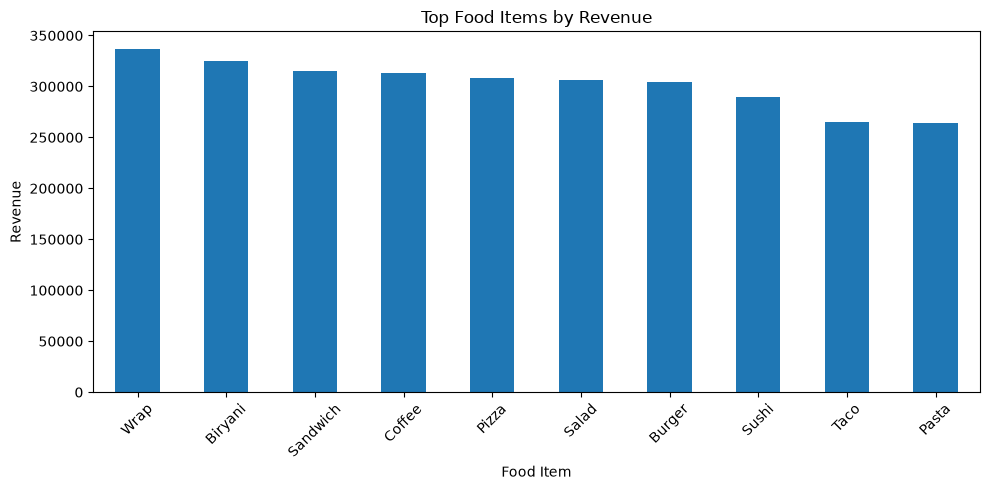

In [28]:
plt.figure(figsize=(10, 5))
food_revenue.head(10).plot(kind="bar")
plt.title("Top Food Items by Revenue")
plt.xlabel("Food Item")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
restaurant_revenue = (
    df.groupby("Restaurant")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

display(restaurant_revenue.head(10))

Restaurant
Healthy Bowl     327202.56
Grill Master     316202.87
Veg Express      315967.22
Pizza Point      315815.32
Cafe Delight     302825.20
Sushi Spot       296465.45
Taco Town        292171.78
Biryani House    290586.02
Pasta Place      289554.91
Burger Hub       281625.98
Name: TotalAmount, dtype: float64

In [30]:
customer_revenue = (
    df.groupby("CustomerID")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

display(customer_revenue.head(10))

CustomerID
1141    14134.08
1695    13501.95
1595    12656.74
1092    11249.61
1774    10878.03
1792    10851.75
1117    10767.46
1394    10762.00
1403    10651.21
1004    10603.11
Name: TotalAmount, dtype: float64

In [31]:
city_revenue = (
    df.groupby("City")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

display(city_revenue)

City
Delhi        661013.09
Mumbai       611626.51
Hyderabad    606399.53
Chennai      581559.79
Bangalore    567818.39
Name: TotalAmount, dtype: float64

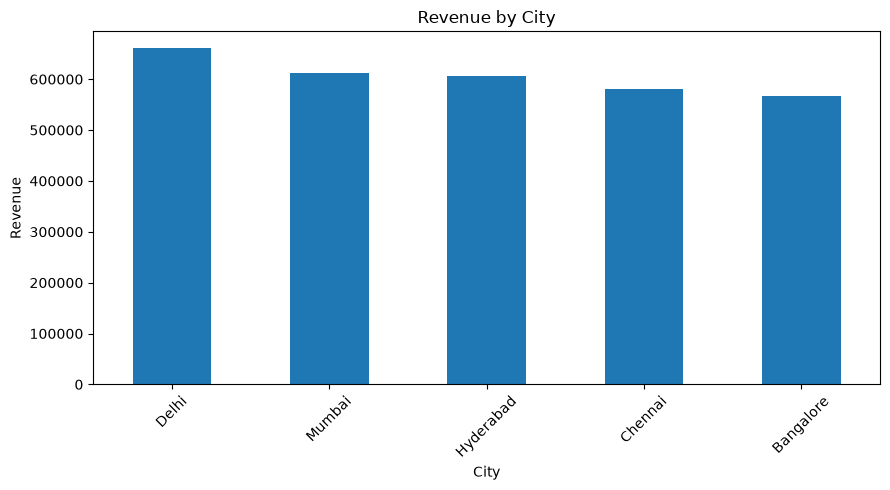

In [32]:
plt.figure(figsize=(9, 5))
city_revenue.plot(kind="bar")
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
payment_distribution = df["PaymentMethod"].value_counts()
display(payment_distribution)

PaymentMethod
UPI     1050
Cash     987
Card     963
Name: count, dtype: int64

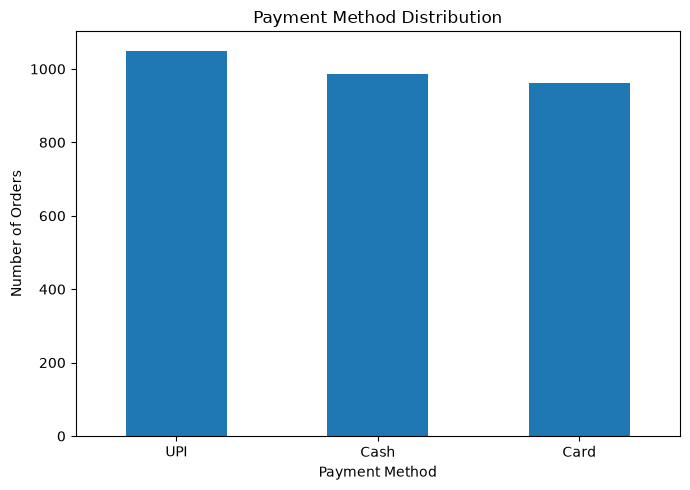

In [34]:
plt.figure(figsize=(7, 5))
payment_distribution.plot(kind="bar")
plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [35]:
rating_distribution = df["CustomerRating"].value_counts().sort_index()
display(rating_distribution)

CustomerRating
1    595
2    592
3    605
4    627
5    581
Name: count, dtype: int64

In [36]:
print("Average Customer Rating:", round(df["CustomerRating"].mean(), 2))

Average Customer Rating: 3.0


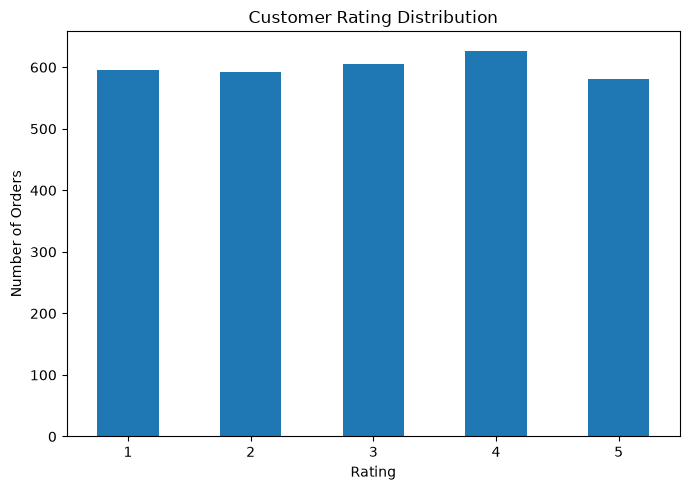

In [37]:
plt.figure(figsize=(7, 5))
rating_distribution.plot(kind="bar")
plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
print("Average Order Value:", round(df["TotalAmount"].mean(), 2))
print("Total Revenue:", round(df["TotalAmount"].sum(), 2))
print("Average Delivery Time:", round(df["DeliveryTime_Minutes"].mean(), 2))

Average Order Value: 1009.47
Total Revenue: 3028417.31
Average Delivery Time: 34.92


In [39]:
weekday_orders = df["Weekday"].value_counts()
display(weekday_orders)

Weekday
Tuesday      460
Sunday       441
Wednesday    440
Saturday     429
Monday       427
Friday       405
Thursday     398
Name: count, dtype: int64

In [40]:
orders_per_order_id = df.groupby("OrderID")["FoodItem"].nunique()

print(
    "Maximum number of different food items per OrderID:",
    orders_per_order_id.max()
)

print(
    "OrderIDs containing more than one food item:",
    (orders_per_order_id > 1).sum()
)

Maximum number of different food items per OrderID: 1
OrderIDs containing more than one food item: 0


In [41]:
basket = (
    df.groupby("CustomerID")["FoodItem"]
    .apply(lambda x: list(set(x)))
)

display(basket.head(10))

CustomerID
1001                              [Pasta, Coffee]
1002                                      [Salad]
1003                [Burger, Pasta, Pizza, Salad]
1004    [Burger, Sandwich, Biryani, Coffee, Taco]
1005                      [Biryani, Pasta, Salad]
1006                     [Burger, Taco, Sandwich]
1007                     [Sushi, Pasta, Sandwich]
1008                              [Wrap, Biryani]
1009           [Biryani, Sandwich, Sushi, Burger]
1010                      [Wrap, Sushi, Sandwich]
Name: FoodItem, dtype: object

In [42]:
all_items = sorted(
    set(item for items in basket for item in items)
)

print("Total unique food items:", len(all_items))
print(all_items)

Total unique food items: 10
['Biryani', 'Burger', 'Coffee', 'Pasta', 'Pizza', 'Salad', 'Sandwich', 'Sushi', 'Taco', 'Wrap']


In [43]:
basket_matrix = pd.DataFrame(
    0,
    index=basket.index,
    columns=all_items
)

for customer_id, items in basket.items():
    basket_matrix.loc[customer_id, items] = 1

display(basket_matrix.head())

,Biryani,Burger,Coffee,Pasta,Pizza,Salad,Sandwich,Sushi,Taco,Wrap
CustomerID,,,,,,,,,,
1001,0,0,1,1,0,0,0,0,0,0
1002,0,0,0,0,0,1,0,0,0,0
1003,0,1,0,1,1,1,0,0,0,0
1004,1,1,1,0,0,0,1,0,1,0
1005,1,0,0,1,0,1,0,0,0,0


In [44]:
frequent_itemsets = apriori(
    basket_matrix.astype(bool),
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets = (
    frequent_itemsets
    .sort_values(by="support", ascending=False)
    .reset_index(drop=True)
)

display(frequent_itemsets.head(20))

,support,itemsets
0,0.359694,(Wrap)
1,0.354592,(Biryani)
2,0.326531,(Coffee)
3,0.320153,(Burger)
4,0.317602,(Pizza)
5,0.317602,(Sandwich)
6,0.317602,(Sushi)
7,0.311224,(Salad)
8,0.297194,(Taco)
9,0.286990,(Pasta)


In [45]:
if len(frequent_itemsets) > 0:
    rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=0.20
    )
else:
    rules = pd.DataFrame()

if not rules.empty:
    rules = rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].copy()

    rules = rules.sort_values(
        by="lift",
        ascending=False
    ).reset_index(drop=True)

    display(rules.head(20))
else:
    print("No association rules were generated.")

,antecedents,consequents,support,confidence,lift
0,"(Coffee, Sandwich)","(Biryani, Sushi)",0.021684,0.236111,1.948538
1,"(Biryani, Taco)","(Sushi, Sandwich)",0.021684,0.212500,1.937209
2,"(Taco, Sandwich)","(Biryani, Sushi)",0.021684,0.223684,1.845983
3,"(Biryani, Taco, Sandwich)",(Sushi),0.021684,0.586207,1.845728
4,"(Sushi, Coffee)","(Biryani, Sandwich)",0.021684,0.217949,1.798650
5,"(Sushi, Taco)","(Biryani, Sandwich)",0.021684,0.215190,1.775883
6,"(Biryani, Burger, Sandwich)",(Sushi),0.020408,0.533333,1.679250
7,"(Biryani, Burger, Sushi)",(Sandwich),0.020408,0.516129,1.625081
8,"(Biryani, Sushi, Taco)",(Sandwich),0.021684,0.515152,1.622003
9,"(Biryani, Coffee, Sandwich)",(Sushi),0.021684,0.515152,1.622003


In [46]:
if not rules.empty:
    display(
        rules.sort_values(
            by="support",
            ascending=False
        ).head(10)
    )

,antecedents,consequents,support,confidence,lift
217,(Biryani),(Wrap),0.130102,0.366906,1.020052
216,(Wrap),(Biryani),0.130102,0.361702,1.020052
139,(Biryani),(Sandwich),0.121173,0.341727,1.075959
136,(Sushi),(Biryani),0.121173,0.381526,1.075959
138,(Biryani),(Sushi),0.121173,0.341727,1.075959
137,(Sandwich),(Biryani),0.121173,0.381526,1.075959
226,(Wrap),(Coffee),0.118622,0.329787,1.009973
141,(Salad),(Biryani),0.118622,0.381148,1.074891
140,(Biryani),(Salad),0.118622,0.334532,1.074891
225,(Coffee),(Wrap),0.118622,0.363281,1.009973


In [47]:
if not rules.empty:
    display(
        rules.sort_values(
            by="confidence",
            ascending=False
        ).head(10)
    )

,antecedents,consequents,support,confidence,lift
3,"(Biryani, Taco, Sandwich)",(Sushi),0.021684,0.586207,1.845728
10,"(Sushi, Coffee, Sandwich)",(Biryani),0.021684,0.566667,1.598082
11,"(Burger, Sushi, Sandwich)",(Biryani),0.020408,0.551724,1.555941
12,"(Sushi, Taco, Sandwich)",(Biryani),0.021684,0.548387,1.546531
6,"(Biryani, Burger, Sandwich)",(Sushi),0.020408,0.533333,1.679250
7,"(Biryani, Burger, Sushi)",(Sandwich),0.020408,0.516129,1.625081
8,"(Biryani, Sushi, Taco)",(Sandwich),0.021684,0.515152,1.622003
9,"(Biryani, Coffee, Sandwich)",(Sushi),0.021684,0.515152,1.622003
17,"(Sushi, Coffee)",(Biryani),0.048469,0.487179,1.373916
20,"(Sushi, Sandwich)",(Biryani),0.052296,0.476744,1.344487


In [48]:
if not rules.empty:
    display(
        rules.sort_values(
            by="lift",
            ascending=False
        ).head(10)
    )

,antecedents,consequents,support,confidence,lift
0,"(Coffee, Sandwich)","(Biryani, Sushi)",0.021684,0.236111,1.948538
1,"(Biryani, Taco)","(Sushi, Sandwich)",0.021684,0.212500,1.937209
2,"(Taco, Sandwich)","(Biryani, Sushi)",0.021684,0.223684,1.845983
3,"(Biryani, Taco, Sandwich)",(Sushi),0.021684,0.586207,1.845728
4,"(Sushi, Coffee)","(Biryani, Sandwich)",0.021684,0.217949,1.798650
5,"(Sushi, Taco)","(Biryani, Sandwich)",0.021684,0.215190,1.775883
6,"(Biryani, Burger, Sandwich)",(Sushi),0.020408,0.533333,1.679250
7,"(Biryani, Burger, Sushi)",(Sandwich),0.020408,0.516129,1.625081
8,"(Biryani, Sushi, Taco)",(Sandwich),0.021684,0.515152,1.622003
9,"(Biryani, Coffee, Sandwich)",(Sushi),0.021684,0.515152,1.622003


In [49]:
if not rules.empty:
    food_combinations = rules[
        (rules["lift"] > 1) &
        (rules["confidence"] >= 0.20)
    ].copy()

    display(food_combinations.head(20))
else:
    food_combinations = pd.DataFrame()

    print("No food combinations were found.")

,antecedents,consequents,support,confidence,lift
0,"(Coffee, Sandwich)","(Biryani, Sushi)",0.021684,0.236111,1.948538
1,"(Biryani, Taco)","(Sushi, Sandwich)",0.021684,0.212500,1.937209
2,"(Taco, Sandwich)","(Biryani, Sushi)",0.021684,0.223684,1.845983
3,"(Biryani, Taco, Sandwich)",(Sushi),0.021684,0.586207,1.845728
4,"(Sushi, Coffee)","(Biryani, Sandwich)",0.021684,0.217949,1.798650
5,"(Sushi, Taco)","(Biryani, Sandwich)",0.021684,0.215190,1.775883
6,"(Biryani, Burger, Sandwich)",(Sushi),0.020408,0.533333,1.679250
7,"(Biryani, Burger, Sushi)",(Sandwich),0.020408,0.516129,1.625081
8,"(Biryani, Sushi, Taco)",(Sandwich),0.021684,0.515152,1.622003
9,"(Biryani, Coffee, Sandwich)",(Sushi),0.021684,0.515152,1.622003


In [50]:
def recommend(item, rules, top_n=5):
    if rules.empty:
        return pd.DataFrame()

    item = str(item).strip()
    recommendations = []

    for _, rule in rules.iterrows():
        antecedents = set(rule["antecedents"])
        consequents = set(rule["consequents"])

        if item in antecedents:
            for food in consequents:
                recommendations.append({
                    "FoodItem": food,
                    "Confidence": rule["confidence"],
                    "Lift": rule["lift"],
                    "Support": rule["support"]
                })

    if not recommendations:
        return pd.DataFrame()

    recommendations = pd.DataFrame(recommendations)

    recommendations = (
        recommendations
        .sort_values(
            by=["Lift", "Confidence", "Support"],
            ascending=False
        )
        .drop_duplicates(subset=["FoodItem"])
        .head(top_n)
        .reset_index(drop=True)
    )

    return recommendations

In [51]:
recommendation_result = recommend(
    "Burger",
    rules,
    top_n=5
)

display(recommendation_result)

,FoodItem,Confidence,Lift,Support
0,Sushi,0.533333,1.679250,0.020408
1,Sandwich,0.516129,1.625081,0.020408
2,Biryani,0.551724,1.555941,0.020408
3,Wrap,0.469880,1.306332,0.049745
4,Coffee,0.421687,1.291416,0.044643


In [52]:
test_items = [
    "Burger",
    "Pizza",
    "Biryani",
    "Wrap",
    "Pasta"
]

In [53]:
for item in test_items:
    print(f"\nRecommendations for {item}")
    display(
        recommend(
            item,
            rules,
            top_n=5
        )
    )


Recommendations for Burger


,FoodItem,Confidence,Lift,Support
0,Sushi,0.533333,1.679250,0.020408
1,Sandwich,0.516129,1.625081,0.020408
2,Biryani,0.551724,1.555941,0.020408
3,Wrap,0.469880,1.306332,0.049745
4,Coffee,0.421687,1.291416,0.044643



Recommendations for Pizza


,FoodItem,Confidence,Lift,Support
0,Sandwich,0.440000,1.385382,0.042092
1,Burger,0.407407,1.272539,0.042092
2,Salad,0.382716,1.229711,0.039541
3,Sushi,0.382716,1.205018,0.039541
4,Wrap,0.417910,1.161850,0.035714



Recommendations for Biryani


,FoodItem,Confidence,Lift,Support
0,Sushi,0.212500,1.937209,0.021684
1,Sandwich,0.212500,1.937209,0.021684
2,Taco,0.414634,1.395164,0.021684
3,Wrap,0.469880,1.306332,0.049745
4,Salad,0.402985,1.294837,0.034439



Recommendations for Wrap


,FoodItem,Confidence,Lift,Support
0,Biryani,0.428571,1.208633,0.045918
1,Pizza,0.379747,1.195669,0.038265
2,Burger,0.382353,1.194282,0.049745
3,Coffee,0.387500,1.186719,0.039541
4,Taco,0.345238,1.161660,0.036990



Recommendations for Pasta


,FoodItem,Confidence,Lift,Support
0,Salad,0.402985,1.294837,0.034439
1,Taco,0.352941,1.187579,0.030612
2,Pizza,0.373134,1.174849,0.031888
3,Biryani,0.413793,1.166956,0.030612
4,Wrap,0.406250,1.129433,0.033163


In [54]:
monthly_orders = (
    df.set_index("OrderDate")
    .resample("MS")["OrderID"]
    .nunique()
)

display(monthly_orders)

OrderDate
2024-01-01    240
2024-02-01    255
2024-03-01    250
2024-04-01    257
2024-05-01    271
2024-06-01    217
2024-07-01    276
2024-08-01    266
2024-09-01    224
2024-10-01    285
2024-11-01    240
2024-12-01    219
Freq: MS, Name: OrderID, dtype: int64

In [55]:
monthly_sales = (
    df.set_index("OrderDate")
    .resample("MS")["TotalAmount"]
    .sum()
)

display(monthly_sales)

OrderDate
2024-01-01    228733.65
2024-02-01    279640.20
2024-03-01    239471.27
2024-04-01    271320.02
2024-05-01    274833.23
2024-06-01    216166.10
2024-07-01    275629.83
2024-08-01    265599.52
2024-09-01    216775.56
2024-10-01    299625.98
2024-11-01    234365.33
2024-12-01    226256.62
Freq: MS, Name: TotalAmount, dtype: float64

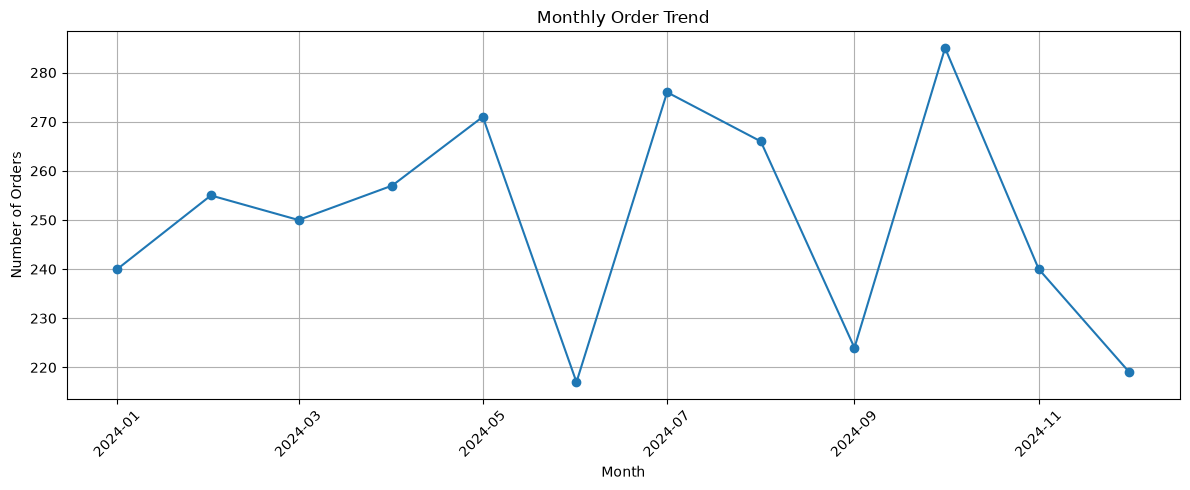

In [56]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()

plt.show()

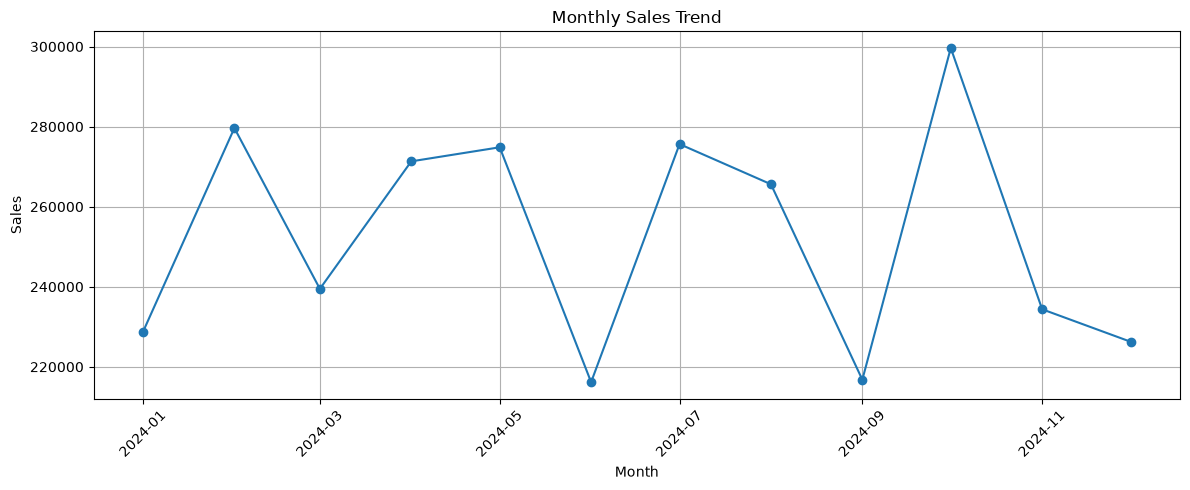

In [57]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()

plt.show()

In [58]:
monthly_summary = pd.DataFrame({
    "Orders": monthly_orders,
    "Sales": monthly_sales
})

monthly_summary["AverageOrderValue"] = (
    monthly_summary["Sales"] /
    monthly_summary["Orders"]
)

display(monthly_summary)

,Orders,Sales,AverageOrderValue
OrderDate,,,
2024-01-01,240,228733.65,953.056875
2024-02-01,255,279640.20,1096.628235
2024-03-01,250,239471.27,957.885080
2024-04-01,257,271320.02,1055.719922
2024-05-01,271,274833.23,1014.144760
2024-06-01,217,216166.10,996.157143
2024-07-01,276,275629.83,998.658804
2024-08-01,266,265599.52,998.494436
2024-09-01,224,216775.56,967.748036


In [59]:
import numpy as np

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [60]:
train_size = int(len(monthly_orders) * 0.80)
train_orders = monthly_orders.iloc[:train_size]

test_orders = monthly_orders.iloc[train_size:]

print("Training observations:", len(train_orders))
print("Testing observations:", len(test_orders))

Training observations: 9
Testing observations: 3


In [61]:
order_model = ARIMA(
    train_orders,
    order=(1, 1, 1)
)

order_model_fit = order_model.fit()
print(order_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                OrderID   No. Observations:                    9
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -35.786
Date:                Fri, 02 Oct 2026   AIC                             77.571
Time:                        19:48:36   BIC                             77.810
Sample:                    01-01-2024   HQIC                            75.964
                         - 09-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4784      0.532     -0.899      0.368      -1.521       0.564
ma.L1         -0.9991    230.401     -0.004      0.997    -452.577     450.579
sigma2       302.7338   6.98e+04      0.004      0.9

In [62]:
test_forecast = order_model_fit.forecast(
    steps=len(test_orders)
)

test_forecast = pd.Series(
    test_forecast,
    index=test_orders.index
)

display(test_forecast)

OrderDate
2024-10-01    265.551419
2024-11-01    245.675168
2024-12-01    255.183035
Freq: MS, Name: predicted_mean, dtype: float64

In [63]:
mae = mean_absolute_error(
    test_orders,
    test_forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test_orders,
        test_forecast
    )
)

print(
    "Order Forecast MAE:",
    round(mae, 2)
)

print(
    "Order Forecast RMSE:",
    round(rmse, 2)
)

Order Forecast MAE: 20.44
Order Forecast RMSE: 23.94


In [64]:
comparison = pd.DataFrame({
    "Actual Orders": test_orders,
    "Predicted Orders": test_forecast
})

display(comparison)

,Actual Orders,Predicted Orders
OrderDate,,
2024-10-01,285,265.551419
2024-11-01,240,245.675168
2024-12-01,219,255.183035


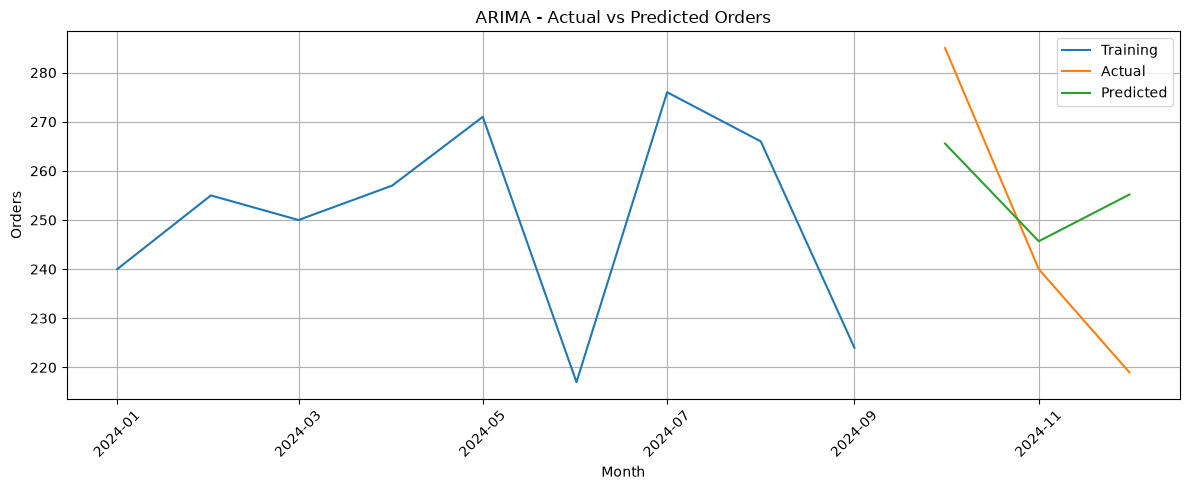

In [65]:
plt.figure(figsize=(12, 5))

plt.plot(
    train_orders.index,
    train_orders,
    label="Training"
)

plt.plot(
    test_orders.index,
    test_orders,
    label="Actual"
)

plt.plot(
    test_forecast.index,
    test_forecast,
    label="Predicted"
)

plt.title("ARIMA - Actual vs Predicted Orders")
plt.xlabel("Month")
plt.ylabel("Orders")

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [66]:
final_order_model = ARIMA(
    monthly_orders,
    order=(1, 1, 1)
)

final_order_model_fit = final_order_model.fit()

print(final_order_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                OrderID   No. Observations:                   12
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -50.168
Date:                Fri, 02 Oct 2026   AIC                            106.336
Time:                        19:49:44   BIC                            107.530
Sample:                    01-01-2024   HQIC                           105.584
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4402      0.427     -1.031      0.302      -1.277       0.396
ma.L1         -0.9990    185.982     -0.005      0.996    -365.517     363.519
sigma2       394.1923   7.33e+04      0.005      0.9

In [67]:
order_forecast = final_order_model_fit.forecast(
    steps=3
)

order_forecast = order_forecast.clip(
    lower=0
)

display(order_forecast)

2025-01-01    265.223507
2025-02-01    244.873923
2025-03-01    253.832689
Freq: MS, Name: predicted_mean, dtype: float64

In [68]:
future_order_dates = pd.date_range(
    start=monthly_orders.index[-1] + pd.offsets.MonthBegin(1),
    periods=3,
    freq="MS"
)

display(future_order_dates)

DatetimeIndex(['2025-01-01', '2025-02-01', '2025-03-01'], dtype='datetime64[ns]', freq='MS')

In [69]:
order_forecast_df = pd.DataFrame({
    "Month": future_order_dates,
    "ForecastedOrders": np.round(
        order_forecast.values,
        0
    ).astype(int)
})

display(order_forecast_df)

,Month,ForecastedOrders
0,2025-01-01,265
1,2025-02-01,245
2,2025-03-01,254


In [70]:
top_food = food_revenue.index[0]

top_restaurant = restaurant_revenue.index[0]

top_city = city_revenue.index[0]

top_payment = payment_distribution.index[0]

In [71]:
print(f"Highest revenue food item: {top_food}")

print(f"Highest revenue restaurant: {top_restaurant}")

print(f"Highest revenue city: {top_city}")

print(f"Most used payment method: {top_payment}")

print(
    f"Average customer rating: "
    f"{df['CustomerRating'].mean():.2f}"
)

print(
    f"Average delivery time: "
    f"{df['DeliveryTime_Minutes'].mean():.2f} minutes"
)

Highest revenue food item: Wrap
Highest revenue restaurant: Healthy Bowl
Highest revenue city: Delhi
Most used payment method: UPI
Average customer rating: 3.00
Average delivery time: 34.92 minutes


In [76]:
train_size_sales = int(len(monthly_sales) * 0.80)

train_sales = monthly_sales.iloc[:train_size_sales]
test_sales = monthly_sales.iloc[train_size_sales:]

print("Training observations:", len(train_sales))
print("Testing observations:", len(test_sales))

Training observations: 9
Testing observations: 3


In [77]:
sales_model = ARIMA(
    train_sales,
    order=(1, 1, 1)
)

sales_model_fit = sales_model.fit()

print(sales_model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:            TotalAmount   No. Observations:                    9
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -95.742
Date:                Fri, 02 Oct 2026   AIC                            197.485
Time:                        19:58:48   BIC                            197.723
Sample:                    01-01-2024   HQIC                           195.877
                         - 09-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4899      0.978     -0.501      0.617      -2.408       1.428
ma.L1          0.7087      0.796      0.890      0.374      -0.852       2.270
sigma2      1.409e+09   4.13e-10   3.41e+18      0.0

In [78]:
test_sales_forecast = sales_model_fit.forecast(
    steps=len(test_sales)
)

test_sales_forecast = pd.Series(
    test_sales_forecast,
    index=test_sales.index
)

display(test_sales_forecast)


OrderDate
2024-10-01    218183.656874
2024-11-01    217493.894734
2024-12-01    217831.777601
Freq: MS, Name: predicted_mean, dtype: float64

In [79]:
sales_mae = mean_absolute_error(
    test_sales,
    test_sales_forecast
)

sales_rmse = np.sqrt(
    mean_squared_error(
        test_sales,
        test_sales_forecast
    )
)

print("Sales Forecast MAE:", round(sales_mae, 2))
print("Sales Forecast RMSE:", round(sales_rmse, 2))


Sales Forecast MAE: 35579.53
Sales Forecast RMSE: 48264.81


In [80]:
sales_comparison = pd.DataFrame({
    "Actual Sales": test_sales,
    "Predicted Sales": test_sales_forecast
})

display(sales_comparison)

,Actual Sales,Predicted Sales
OrderDate,,
2024-10-01,299625.98,218183.656874
2024-11-01,234365.33,217493.894734
2024-12-01,226256.62,217831.777601


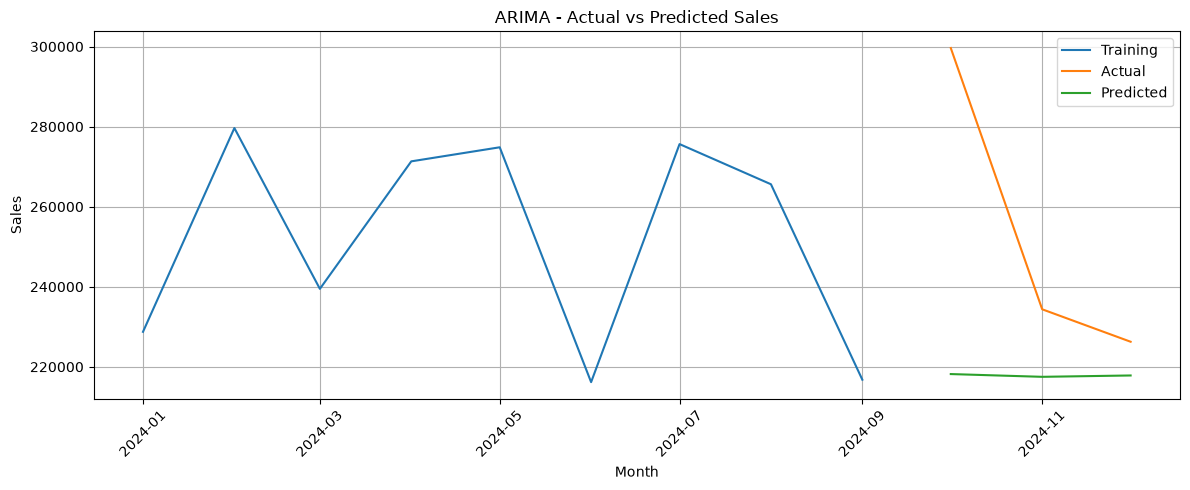

In [81]:
plt.figure(figsize=(12, 5))

plt.plot(
    train_sales.index,
    train_sales,
    label="Training"
)

plt.plot(
    test_sales.index,
    test_sales,
    label="Actual"
)

plt.plot(
    test_sales_forecast.index,
    test_sales_forecast,
    label="Predicted"
)

plt.title("ARIMA - Actual vs Predicted Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [82]:
final_sales_model = ARIMA(
    monthly_sales,
    order=(1, 1, 1)
)

final_sales_model_fit = final_sales_model.fit()

sales_forecast = final_sales_model_fit.forecast(
    steps=3
)

sales_forecast = sales_forecast.clip(lower=0)

display(sales_forecast)


2025-01-01    228209.199912
2025-02-01    228777.036861
2025-03-01    228942.171613
Freq: MS, Name: predicted_mean, dtype: float64

In [83]:
future_sales_dates = pd.date_range(
    start=monthly_sales.index[-1] + pd.offsets.MonthBegin(1),
    periods=3,
    freq="MS"
)

sales_forecast_df = pd.DataFrame({
    "Month": future_sales_dates,
    "ForecastedSales": np.round(
        sales_forecast.values,
        2
    )
})

display(sales_forecast_df)


,Month,ForecastedSales
0,2025-01-01,228209.20
1,2025-02-01,228777.04
2,2025-03-01,228942.17


In [84]:
forecast_summary = pd.DataFrame({
    "Month": future_order_dates,
    "ForecastedOrders": order_forecast_df["ForecastedOrders"],
    "ForecastedSales": sales_forecast_df["ForecastedSales"]
})

display(forecast_summary)


,Month,ForecastedOrders,ForecastedSales
0,2025-01-01,265,228209.20
1,2025-02-01,245,228777.04
2,2025-03-01,254,228942.17


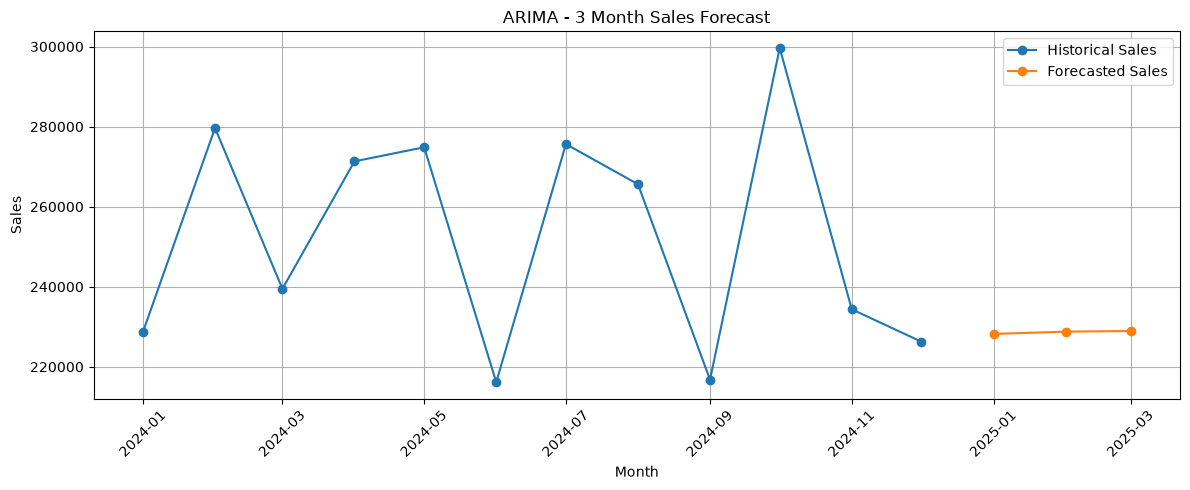

In [85]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales,
    marker="o",
    label="Historical Sales"
)

plt.plot(
    sales_forecast_df["Month"],
    sales_forecast_df["ForecastedSales"],
    marker="o",
    label="Forecasted Sales"
)

plt.title("ARIMA - 3 Month Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
